# Controlled LLM tuning and a real optimizer update

This supplemental experiment keeps the expanded corpus, vocabulary, split, and architecture fixed. It compares six configurations, selects using held-out loss, confirms across initialization seeds, and records a genuine step-1,000 update. The original two experiments remain available.

**Prediction:** balanced exposure may improve grammar and contrast loss. Learning-rate changes may help optimization, but benchmark gains are uncertain. Vocabulary fixes coverage at 27/48.

**Selection:** minimize final category-macro validation loss, subject to original-panel loss staying within 5% of the matched uniform, LR 0.001 baseline. Keep every trial, including failures.

**Reproduction:** run from the repository root with its Python dependencies. Each execution creates a new study folder. This notebook executes the study functions directly; its outputs are recorded results.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import sys
from IPython.display import Markdown, SVG, display
ROOT = Path.cwd()
assert (ROOT / 'scripts/tuning_study.py').exists(), 'Run from repository root'
sys.path.insert(0, str(ROOT))
from scripts.tuning_study import Study, read_json
study_path = ROOT / 'tuning_runs' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
study = Study(study_path)
print('Study:', study_path)

Study: /Users/shahdevansh/Documents/Codex/custom-llm-assignment-2026-09-22/tuning_runs/20260923T065432_482471Z


## Freeze controls before training

The original validation panel is retained. A second panel contains ten starter, five grammar, and five contrast passages. Each category contributes equally to the selection metric. The training-document RNG stays fixed across all runs; confirmation seeds change initialization only. Each sampler uses the same minibatches for all learning rates. The update example is chosen from the predetermined step-1,000 minibatch before training.

In [2]:
study.prepare()

{
  "training_groups": {
    "starter": 4148,
    "grammar": 464,
    "contrasts": 341
  },
  "frozen_panels": {
    "original": 20,
    "starter": 10,
    "grammar": 5,
    "contrasts": 5
  },
  "preselected_probes": {
    "uniform": {
      "update": 1000,
      "train_index": 3969,
      "passage": "the farmers are tired before work .",
      "prefix": "the farmers",
      "target": "are",
      "token_id": 14,
      "coordinate": 0,
      "parameter": "transformer.wte.weight (tied to lm_head.weight)",
      "rule": "first grammar passage in the predetermined update-1000 batch; third token; coordinate 0"
    },
    "balanced": {
      "update": 1000,
      "train_index": 1859,
      "passage": "a gardener seems calm today .",
      "prefix": "a gardener",
      "target": "seems",
      "token_id": 225,
      "coordinate": 0,
      "parameter": "transformer.wte.weight (tied to lm_head.weight)",
      "rule": "first grammar passage in the predetermined update-1000 batch; third token; 

## Six configurations

Peak learning rates: 0.0003, 0.001, and 0.003. Samplers: uniform passages; or 16 starter, eight grammar, eight contrast passages per batch. Every model starts from the same saved seed-42 weights and completes 3,000 updates. AdamW uses the supplied warmup, cosine decay, moments, weight decay, and gradient clipping. Losses average non-padding next-token targets. Every run saves its optimizer state and actual update evidence.

In [3]:
study.sweep()

number of parameters: 0.12M


uniform_lr0.0003_seed42: macro=1.216935, original=0.838709, 17.9s


number of parameters: 0.12M


uniform_lr0.001_seed42: macro=0.906704, original=0.746731, 17.0s


number of parameters: 0.12M


...

balanced_lr0.0003_seed42: macro=0.981257, original=0.874261, 18.9s


number of parameters: 0.12M


balanced_lr0.001_seed42: macro=0.893670, original=0.749250, 17.4s


number of parameters: 0.12M


balanced_lr0.003_seed42: macro=0.834300, original=0.755719, 17.4s


## Select using validation loss

The language suite has not been loaded or scored by this study. The selection artifact is written before confirmation and evaluation.

In [4]:
selection = study.select()

{
  "selected_config": "balanced_lr0.003",
  "sampler": "balanced",
  "learning_rate": 0.003,
  "baseline_config": "uniform_lr0.001",
  "original_panel_limit": 0.7840672194957733,
  "eligible": [
    "uniform_lr0.001",
    "uniform_lr0.003",
    "balanced_lr0.001",
    "balanced_lr0.003"
  ],
  "selected_utc": "2026-09-23T06:56:18.577065+00:00",
  "basis": "final held-out category-macro loss with original-panel guardrail; no suite scores read"
}


## Confirm and test instrumentation

Repeat the baseline and selected setting with seeds 43 and 44. Replay the selected seed-42 run with update instrumentation disabled and compare all final weights and recorded validation losses exactly.

In [5]:
study.confirm()

number of parameters: 0.12M


uniform_lr0.001_seed43: macro=0.906659, original=0.730630, 15.9s


number of parameters: 0.12M


balanced_lr0.003_seed43: macro=0.958437, original=0.752226, 17.0s


number of parameters: 0.12M


...

number of parameters: 0.12M


balanced_lr0.003_seed44: macro=0.924341, original=0.749294, 14.3s


number of parameters: 0.12M


balanced_lr0.003_seed42_no_instrumentation: macro=0.834300, original=0.755719, 14.2s


{
  "instrumented_run": "balanced_lr0.003_seed42",
  "control_run": "balanced_lr0.003_seed42_no_instrumentation",
  "identical_final_weights": true,
  "identical_history": true
}


## Evaluate after selection

Run the unchanged public 48-case suite on all instrumented final checkpoints. Report coverage, correct answers, case gains, and regressions. These scores do not revise the selected configuration.

In [6]:
study.evaluate()

number of parameters: 0.12M
Language evals (final): 24/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
uniform_lr0.0003_seed42: 24/48; coverage 27/48
number of parameters: 0.12M


Language evals (final): 24/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
uniform_lr0.001_seed42: 24/48; coverage 27/48
number of parameters: 0.12M
Language evals (final): 24/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
uniform_lr0.003_seed42: 24/48; coverage 27/48
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 15/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
balanced_lr0.0003_seed42: 25/48; coverage 27/48
number of parameters: 0.12M
Language evals (final): 26/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
balanced_lr0.001_seed42: 26/48; coverage 27/48
number of parameters: 0.12M


Language evals (final): 26/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
balanced_lr0.003_seed42: 26/48; coverage 27/48
number of parameters: 0.12M
Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 7/8 correct; 8 scorable
uniform_lr0.001_seed43: 25/48; coverage 27/48
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 7/8 correct; 8 scorable
balanced_lr0.003_seed43: 25/48; coverage 27/48
number of parameters: 0.12M
Language evals (final): 26/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
uniform_lr0.001_seed44: 26/48; coverage 27/48
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 1/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
balanced_lr0.003_seed44: 25/48; coverage 27/48
[
  {
    "seed": 42,
    "baseline": "uniform_lr0.001_seed42",
    "selected": "balanced_lr0.003_seed42",
    "baseline_correct": 24,
    "selected_correct": 26,
    "macro_loss_change": -0.07240392764409376,
    "original_loss_change": 0.008987843990325928,
    "guardrail_met": true,
    "gains": [
      "lang_28",
      "lang_29"
    ],
    "regressions": []
  },
  {
    "seed": 43,
    "baseline": "uniform_lr0.001_seed43",
    "selected": "balanced_lr0.003_seed43",
    "baseline_correct": 25,
    "selected_correct": 25,
    "macro_loss_change": 0.051777323087056515,
    "original_loss_change": 0.021595656871795654,
    "guardrail_met": true,
    "gains": [
      "lang_21"
    ],
    "regressions": [
      "lang_22"
    ]
  },
  {
 

## Verify saved evidence

Reconstruct the original baseline, check fixed inputs and initial weights, replay every saved evaluation, and reproduce each step-1,000 update from its weights, optimizer state, and minibatch. Compare the selected coordinate with the AdamW equation.

In [7]:
checks = study.verify()

number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 24/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 24/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 24/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 0/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 15/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


...

Language evals (final): 26/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 7/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 7/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 26/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 2/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M


Language evals (final): 25/48; 27/48 cases have usable vocabulary/context.
  extend_corpus: 1/24 correct; 3 scorable
  starter_patterns: 16/16 correct; 16 scorable
  starter_transfer: 8/8 correct; 8 scorable
number of parameters: 0.12M
number of parameters: 0.12M
96 verification checks passed, including every checkpoint evaluation and every recorded optimizer update.


## Results, interpretation, and next experiments

The report below is generated from the executed study's saved measurements. All weights change in an optimizer step; the selected coordinate illustrates that update. Individual target probabilities and validation losses can move in different directions.

Report: /Users/shahdevansh/Documents/Codex/custom-llm-assignment-2026-09-22/tuning_runs/20260923T065432_482471Z/REPORT.md


# Controlled tuning study

The expanded corpus, vocabulary, split, and architecture were held fixed. Six configurations were screened at seed 42. Selection used final category-macro validation loss with a 5% original-panel guardrail. The chosen setting and baseline were repeated at seeds 43 and 44 before loading the language suite.

Selected configuration: **balanced_lr0.003**. The three category losses each average non-padding token losses within their panel, then receive equal weight. The balanced training batches contain exactly 16 starter, eight grammar, and eight contrast passages. Token counts vary by passage length.

| Sampler | Peak LR | Original loss | Grammar loss | Contrast loss | Macro loss | Eligible | Correct / 48 |
|---|---:|---:|---:|---:|---:|---|---:|
| uniform | 0.0003 | 0.838709 | 1.372893 | 1.532926 | 1.216935 | No | 24 |
| uniform | 0.001 | 0.746731 | 1.226820 | 0.789062 | 0.906704 | Yes | 24 |
| uniform | 0.003 | 0.726566 | 1.210648 | 0.822802 | 0.913143 | Yes | 24 |
| balanced | 0.0003 | 0.874261 | 1.085320 | 1.013715 | 0.981257 | No | 25 |
| balanced | 0.001 | 0.749250 | 1.054310 | 0.875585 | 0.893670 | Yes | 26 |
| balanced | 0.003 | 0.755719 | 1.061898 | 0.688812 | 0.834300 | Yes | 26 |

## Paired confirmation

| Seed | Baseline correct | Selected correct | Macro loss change | Original loss change | Guardrail | Gains | Regressions |
|---|---:|---:|---:|---:|---|---|---|
| 42 | 24 | 26 | -0.072404 | +0.008988 | Pass | lang_28, lang_29 | None |
| 43 | 25 | 25 | +0.051777 | +0.021596 | Pass | lang_21 | lang_22 |
| 44 | 26 | 25 | +0.027321 | +0.016163 | Pass | None | lang_28 |

Mean correct answers: baseline **25.00/48**, selected **25.33/48**. Mean paired macro-loss change: **+0.002231**. Coverage remains **27/48** in every run. Negative loss changes indicate improvement. Seeds 43 and 44 are confirmation runs; seed 42 was used for selection.

## A real update at step 1,000

Preselected training passage: `a gardener seems calm today .`. Prefix: `a gardener`. Target: `seems`. Tracked parameter: embedding row 225, coordinate 0. Input/output embeddings share this weight.

| Measurement | Before | After |
|---|---:|---:|
| Batch loss | 0.6528248191 | 0.6405624747 |
| Target probability | 0.9928501844 | 0.9925804138 |
| Original validation loss | 0.7800863981 | 0.7811573148 |
| Category-macro validation loss | 0.8533952435 | 0.8521275123 |
| Embedding coordinate | -0.2060003132 | -0.2053688616 |

- Actual learning rate: `0.0024088125601`; raw gradient: `-0.000110582019261`; clipped gradient: `-0.000110582019261`.
- Gradient norm: `0.443407833576`; clipping multiplier: `1`; actual coordinate change: `0.00063145160675`.
- Adam first moment: `-2.31193407672e-05` → `-3.18656093441e-05`; second moment: `1.51553862793e-08` → `1.5009035792e-08`.

AdamW carries moving averages of gradients and squared gradients. Bias correction and adaptive scaling determine the gradient contribution, while weight decay shrinks the existing weight. The float64 reconstruction below is compared with the actual float32 optimizer update; the complete checkpoint replay matches every resulting weight exactly. [PyTorch AdamW](https://docs.pytorch.org/docs/2.14/generated/torch.optim.AdamW.html).

```text
m_hat = m_after / (1 - 0.9^1000)
v_hat = v_after / (1 - 0.95^1000)
delta = -lr * 0.01 * weight_before - lr * m_hat / (sqrt(v_hat) + 1e-8)
formula delta = 0.000631451075072
actual delta  = 0.00063145160675
```

All weights were updated together. The before/after measurements describe that whole optimizer step. A single coordinate cannot establish the cause of the prediction change. The passage, token and coordinate were fixed before training; every run retains its update evidence, including unfavorable changes.

## Learning curves



## Verification and limits

- 96 checks passed. The original expanded baseline was reproduced bit for bit. An uninstrumented selected run reproduced both final weights and the complete loss history.
- Every saved final checkpoint was reevaluated and each recorded update was reconstructed from saved weights, optimizer moments, and its actual minibatch.
- Confidence is high in the saved measurements. Three seeds and small, template-sharing validation panels support limited conclusions about this corpus. Confidence in broader language transfer remains low.
- The 48 public cases are a development benchmark. Their scores were read after selection. Vocabulary limits scorable cases to 27; all other cases receive zero credit.
- The original five article errors remain in the fixed corpus. Source grouping and passage-level balance do not equal token-level balance.

## Next improvements

1. Broaden vocabulary using independent teaching material; measure coverage separately from accuracy.
2. Correct article errors and diversify grammar and contrast constructions in a new corpus version.
3. Hold out entire template families before further tuning to measure transfer beyond shared templates.
4. Extend training only where late validation curves continue to improve; preserve a separate selection set.
5. Consider model size or tokenization changes after these data and optimization checks, within assignment rules.

## Reproduce

Run `custom_llm_tuning.ipynb` from the repository root. It creates a new timestamped study directory, freezes its protocol, executes the sweep and confirmations, evaluates all candidates, and verifies the saved evidence. The original experiment ledger and artifacts are retained.


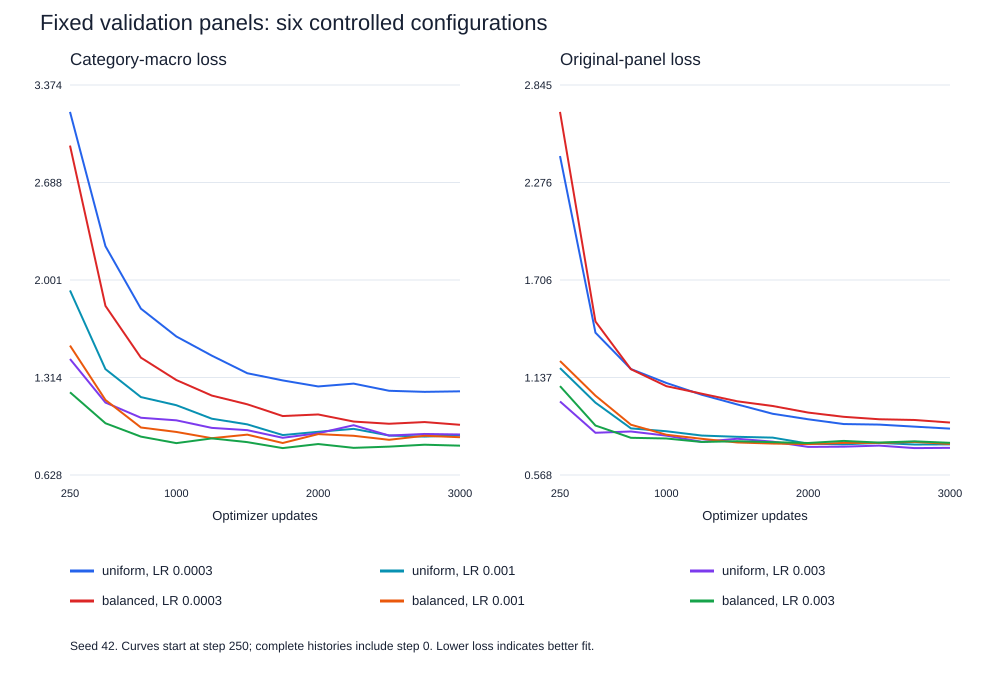

In [8]:
summary = study.report()
display(Markdown((study_path / 'REPORT.md').read_text().replace('![Validation curves](curves.svg)', '')))
display(SVG(filename=str(study_path / 'curves.svg')))

## Post-run interpretation

The selected seed-42 run improved from 24/48 to 26/48. Confirmation seed 43 stayed at 25/48, and seed 44 fell from 26/48 to 25/48. Category-macro validation loss increased in both confirmation runs. These results do not establish a reliable advantage for the selected setting. Keep the baseline as the default while retaining the candidate and all its evidence.

See [the findings and recommendations](docs/tuning_findings.md) for the confirmation-only comparison and the measured step-1,000 tradeoffs. [Exportable Matplotlib figure](tuning_runs/20260923T065432_482471Z/curves_matplotlib.svg).